In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


## Engine

In [2]:
class Value:
    def __init__(self, data, children = (), _operation = '', label=''):
        self.data = data
        self.children = children
        self._operation = _operation
        self.grad = 0
        self._backward = lambda :  None #(do nothing,)
        self._prev = set(children)
        self.label = label


    def __repr__(self):
        return f"{self.label} : {self.data}"
 

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value((self.data + other.data), (self, other), '+')
        
        def _backward():
            self.grad += out.grad * 1
            other.grad += out.grad * 1
        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

        
         
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value((self.data * other.data),  (self, other), '*')
        
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data  
        out._backward = _backward

        return out

    def __rmul__(self, other):
            return self * other


    def __truediv__(self, other):
            return self * other**-1 


    def __neg__(self):
        return self * -1


    def __sub__(self, other):
        return self + (-other)


    def __pow__(self, other):
        assert isinstance(other, (int, float)) #asserting raises AssertionError if False (so if not raising to int of float then something going wrong)
        out = Value(self.data ** other, (self, ), f"^{other}")

        def _backward():
            self.grad +=  other * (self.data **(other - 1)) * out.grad
        out._backward = _backward

        return out

    def __exp__(self):
        x = self.data
        out = Value((np.exp(x)), (self,), 'exp' )

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
              


    def tanh(self):
        x = self.data
        t =(math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out


    def backward(self):

        final_order = []
        visited = set()
        def build_topological(i):
            if i not in visited:
                visited.add(i)
                for children in i.children:
                    build_topological(children)
                final_order.append(i)
        build_topological(self)

        self.grad = 1.0
        for node in reversed(final_order):
            node._backward()







## So can visualise

In [3]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) 
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._operation:
            dot.node(name=str(id(n)) + n._operation, label=n._operation)
            dot.edge(str(id(n)) + n._operation, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._operation)
    
    return dot

## small backwards pass test

In [4]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(1.0, label = 'c')
d = Value(0.5, label = 'd')

e = c + d
f = a * b 
e.label = 'e'
f.label = 'f'

o = e + f
o.label = 'o'
L = o.tanh()
L.label = 'L'



In [6]:
L.backward()

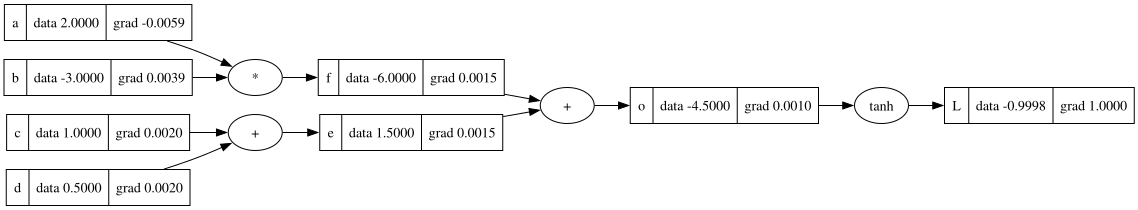

In [7]:
draw_dot(L)

# building out the neural net

In [8]:
class Neuron():
    def __init__(self, n_inputs):
        self.w = [Value(np.random.uniform(-1, 1)) for _ in range(n_inputs)]
        self.b = Value(np.random.uniform(-1, 1))

    def parameters(self):
        return self.w + [self.b]


    def __call__(self, x):
        assert len(self.w) == len(x)
        initial = sum((wi * xi for wi, xi in zip(self.w, x)),  self.b)
        out = initial.tanh()

        return out


In [9]:
class Layer():
    def __init__(self, n_inputs, n_outputs):
        self.neurons = [Neuron(n_inputs) for i in range(n_outputs)]

    def parameters(self):
        layer_parameters = []
        for neuron in self.neurons:
            params = neuron.parameters()
            layer_parameters.extend(params)
        return layer_parameters

    def __call__(self, x):
        return [n(x) for n in self.neurons]

    def __repr__(self):
        return f"{self.neurons}"

In [10]:
class MLP():
    def __init__(self, n_inputs, n_outputs):
        shape = [n_inputs] + n_outputs
        self.layers = [Layer(shape[i], shape[i+1]) for i in range(len(shape)-1)]

    def parameters(self):
        MLP_parameters = []
        for layer in self.layers:
            params = layer.parameters()
            MLP_parameters.extend(params)
        return MLP_parameters

   

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) 
        return x[0] if len(x) == 1 else x



## Training test

In [11]:
m = MLP( 3, [4, 4, 1])

Xs = [
    [3.0, 1.0, -0.5],
    [2.0, 1.25, -3.0],
    [-4.0, -1.0, 2.0]]

Ys = [0.5, 1.0, -1.0]
new_Ys = []
for y in Ys:
    y = Value(y)
    new_Ys.append(y)

y_pred = [m(x) for x in Xs]

y_pred

[ : 0.9014270642692015,  : 0.19302348633280983,  : -0.19208713330564117]

In [15]:
for k in range(1_000):
    y_pred = [m(x) for x in Xs]
    loss = sum((y-pred)**2 for y, pred in zip(new_Ys, y_pred))

    for p in m.parameters():
        p.grad = 0.0
    loss.backward()

    step_size = 0.01

    for p in m.parameters():
        p.data += -step_size * p.grad

    if k % 100 == 0:
        print(k, loss)
    

0  : 0.0025425210100204288
100  : 0.002292433131317816
200  : 0.002086510468681131
300  : 0.0019140469532194083
400  : 0.0017675333439399225
500  : 0.0016415475169750365
600  : 0.001532076932750041
700  : 0.0014360888816464946
800  : 0.0013512488699662728
900  : 0.001275730813500387


In [13]:
y_pred

[ : 0.5024756798281608,  : 0.9598631253371483,  : -0.9695337061245508]